# Your first simulation: a rectangular waveguide

In this tutorial we simulate a 200 mm long rectangular waveguide, compute its
S- and Z-parameters between 0.5 and 5 GHz, and check them against the
closed-form solution.

Along the way we meet the three objects every analysis uses: the **project**
(`EMProject`), which owns the folder the results are saved in; the **part**
we simulate; and the **frequency-domain solver**, `proj.fds`.

**Prerequisites**

* cavsim3d installed as described in [Getting Started](../../getting_started.md).
* A Jupyter notebook started in an empty folder. The tutorials write their
  results to a `simulations/` subfolder of the folder they run in.
* About five minutes; the whole notebook runs in under a minute.

## 1. Set up the model

### 1.1 Create a project

A project is a folder on disk. Everything we compute is saved there as soon as
it is computed.

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="first_simulation", base_dir="./simulations", overwrite=True)

✅ Creating new project 'first_simulation' at simulations\first_simulation


The output confirms that a new project was created in
`simulations/first_simulation`. `overwrite=True` deletes a previous run with
the same name, so the tutorial starts from scratch each time you run it.

### 1.2 Add a waveguide

We add one part to the project: a rectangular waveguide with a cross-section
of 100 mm × 50 mm and a length of 200 mm. **All lengths are in metres.**
`maxh` is the largest allowed mesh element size, also in metres.

In [2]:
proj.create_primitive("rwg", name="guide", a=0.1, b=0.05, L=0.2, maxh=0.02)

proj.parts

{'guide': <cavsim3d.geometry.primitives.RectangularWaveguide at 0x25310d75e90>}

`proj.parts` lists the parts of the project by name. There is one part,
`guide`. It was meshed as soon as it was created.

### 1.3 Look at the mesh

`proj.geo` is the project's geometry. `show('mesh')` draws the mesh the solver
will use. Drag to rotate it, scroll to zoom.

In [3]:
proj.geo.show("mesh")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

You should see a box 0.1 m wide in x, 0.05 m high in y and 0.2 m long in z,
filled with tetrahedra. The text summary gives the same information in
numbers:

In [4]:
proj.geo.print_info()


RectangularWaveguide Geometry Information
Geometry type:          RectangularWaveguide
Compute method:         numeric
Supports analytical:    True
Boundary condition:     left|right|top|bottom

Component Tag:
  Full:                 RectangularWaveguide:a9dccab0
  Geometry hash:        a9dccab0e52c9952...

Cache status:           NOT CACHED

Mesh generated:         True
  Vertices:             232
  Elements:             642
  Ports:                ['port1', 'port2']


Notice the line `Ports: ['port1', 'port2']`: `port1` is the end face at
z = 0 and `port2` the end face at z = L. Every other face is a perfectly
conducting wall.

### 1.4 Check the ports

Before solving, we ask the solver which ports it found and in which order.
This order is the row and column order of the S-matrix we are about to
compute.

In [5]:
proj.fds.print_port_map()


Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 642
 idx  port      geometry    dims [mm]                 carries       role
   0  port1     rectangular area=5000.0 mm^2          TE/TM         external
   1  port2     rectangular area=5000.0 mm^2          TE/TM         external

nportmodes accepts:
  int   nportmodes=1
  list  nportmodes=[1, 1]   (one entry per port, this order)
  dict  nportmodes={'port1': 1, 'port2': 1, 'default': 1}


Two external ports, `port1` and `port2`, both with a rectangular cross-section
of 5000 mm².

## 2. Solve and look at the results

### 2.1 Run the frequency sweep

The waveguide's lowest mode, TE10, propagates above its cutoff frequency
$f_c = c_0 / 2a \approx 1.5$ GHz. We sweep from 0.5 to 5 GHz in steps of
0.1 GHz (46 samples), so the sweep crosses the cutoff.

In [6]:
res = proj.fds.solve(fmin=0.5, fmax=5.0, nsamples=46)

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 2 total modes


Saved port modes to simulations\first_simulation\fds\port_modes\port_modes.pkl

FDS Solve: 0.5000 - 5.0000 GHz, 46 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 44.21s (total iteration steps: 8662)


Saved port modes to simulations\first_simulation\fds\port_modes\port_modes.pkl


The log shows the three stages of a solve: the system matrices are assembled,
the port modes are computed (one TE10 mode per port, with its cutoff
wavenumber `kc` = π/a), and the sweep runs. The sweep takes about half a
minute.

### 2.2 Read the results

`solve()` returns a dictionary. The frequencies are in Hz, and `'S'` holds one
2 × 2 S-matrix per frequency.

In [7]:
f = res["frequencies"]
S = res["S"]

print("frequencies:", f.shape, f"{f[0] / 1e9:.2f} ... {f[-1] / 1e9:.2f} GHz")
print("S-matrices: ", S.shape)

frequencies: (46,) 0.50 ... 5.00 GHz
S-matrices:  (46, 2, 2)


`S[k, i, j]` is the S-parameter from port `j+1` to port `i+1` at frequency
`f[k]`. Print the reflection $|S_{11}|$ and the transmission $|S_{21}|$ at
1.0 GHz (below cutoff), 2.5 GHz and 4.5 GHz:

In [8]:
for k in (5, 20, 40):
    print(f"{f[k] / 1e9:4.1f} GHz   |S11| = {abs(S[k, 0, 0]):.2e}   |S21| = {abs(S[k, 1, 0]):.2e}")

 1.0 GHz   |S11| = 8.43e-07   |S21| = 9.27e-03
 2.5 GHz   |S11| = 4.04e-06   |S21| = 1.00e+00
 4.5 GHz   |S11| = 1.18e-03   |S21| = 1.00e+00


Below cutoff the wave cannot travel down the guide: its field decays along the
length and only a small fraction reaches the far port ($|S_{21}| \approx 0.009$
at 1 GHz). Above cutoff the lossless guide transmits everything:
$|S_{21}| = 1$.

$|S_{11}|$ is essentially zero at all three frequencies: the guide is uniform,
so nothing reflects the wave. (The S-parameters are referred to the port
mode's own wave impedance, which keeps a uniform guide matched even below
cutoff; [Ports and port modes](../../explanation/ports.md) has the details.)

### 2.3 Plot the S-parameters

The same results are available as a result object, `proj.fds.fom` (the
*full-order model*). Its `plot_s` method takes a list of parameter labels. A
label names the excitation first, then the response:
`'<port>(<mode>)<port>(<mode>)'`. So `'1(1)2(1)'` is $S_{21}$: excite mode 1
at port 1, and read mode 1 at port 2.

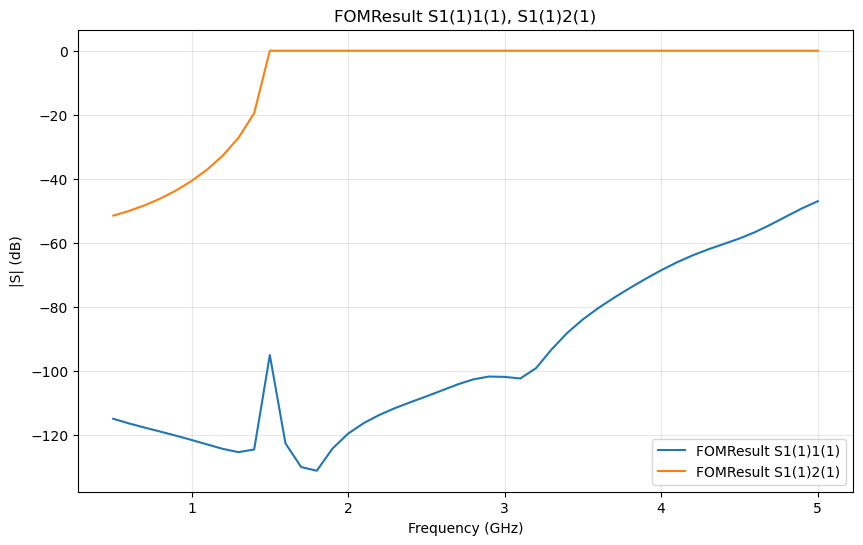

In [9]:
fom = proj.fds.fom
fig, ax = fom.plot_s(["1(1)1(1)", "1(1)2(1)"])

$S_{21}$ climbs from about −50 dB at 0.5 GHz to 0 dB at the cutoff near
1.5 GHz and stays there. $S_{11}$ stays between about −130 and −50 dB. Its
exact value is zero, so this is numerical noise; it grows towards the top of
the band, where the mesh resolves the wave less well.

## 3. Check against the exact solution

### 3.1 Overlay the closed-form S-parameters

`RWGAnalytical` computes the exact S- and Z-parameters of the same waveguide.
It takes the frequency range in GHz.

We draw a 2 × 2 grid of plots: magnitude in dB on the top row, phase on the
bottom row, $S_{11}$ on the left and $S_{21}$ on the right. In each panel the
exact solution is a line and our 46 samples are circles.

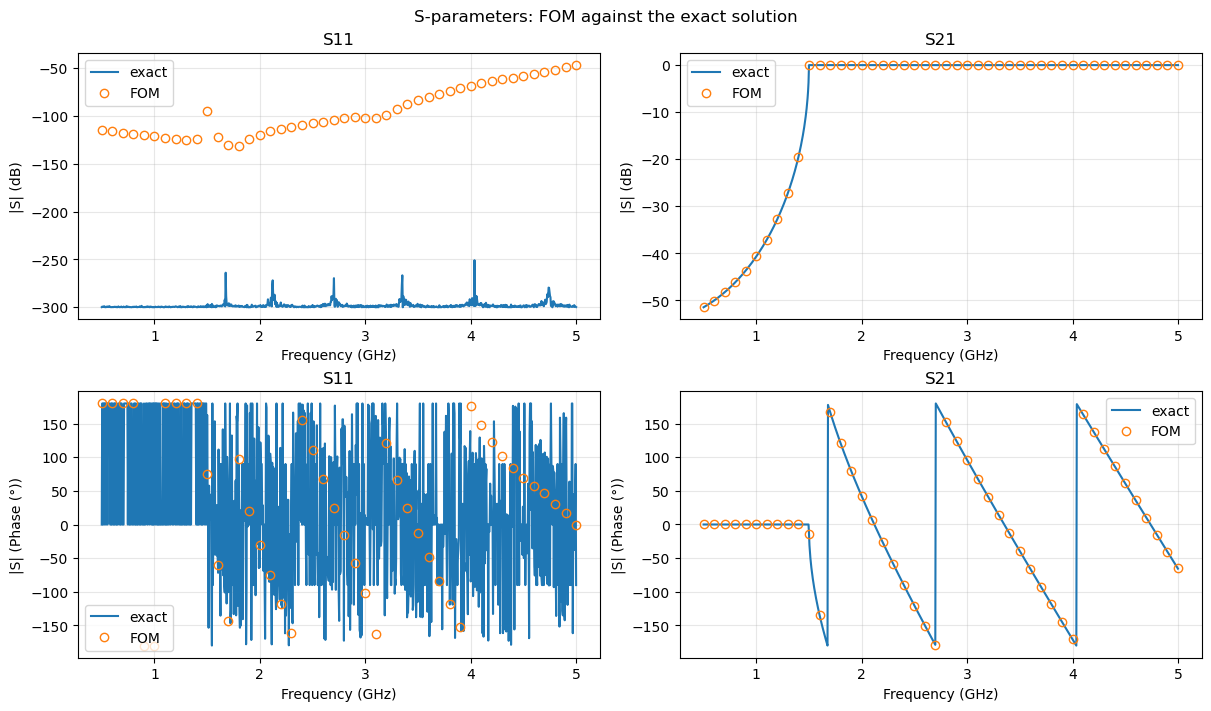

In [10]:
import matplotlib.pyplot as plt

from cavsim3d.analytical import RWGAnalytical

ana = RWGAnalytical(a=0.1, b=0.05, L=0.2, freq_range=(0.5, 5.0))

fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"   # excitation first: '1(1)2(1)' is S21
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_s([label], plot_type=kind, ax=ax, label="exact")
        fom.plot_s([label], plot_type=kind, ax=ax, label="FOM",
                   lw=0, marker="o", mfc="none", title=f"S{ij}")
fig.suptitle("S-parameters: FOM against the exact solution")
plt.show()

In the $S_{21}$ panels the circles lie on the exact curves across the whole
band, through the cutoff and up to 5 GHz. The phase wraps several times
because the guide is more than a wavelength long at the top of the band.

The exact $S_{11}$ is zero (its flat line at −300 dB is just the plotting
floor), so the $S_{11}$ panels show only the FOM's numerical noise, and its
phase is meaningless. In any structure that is not uniform, these two panels
carry the reflections.

### 3.2 Overlay the closed-form Z-parameters

The same grid for the impedance matrix, with `plot_z`:

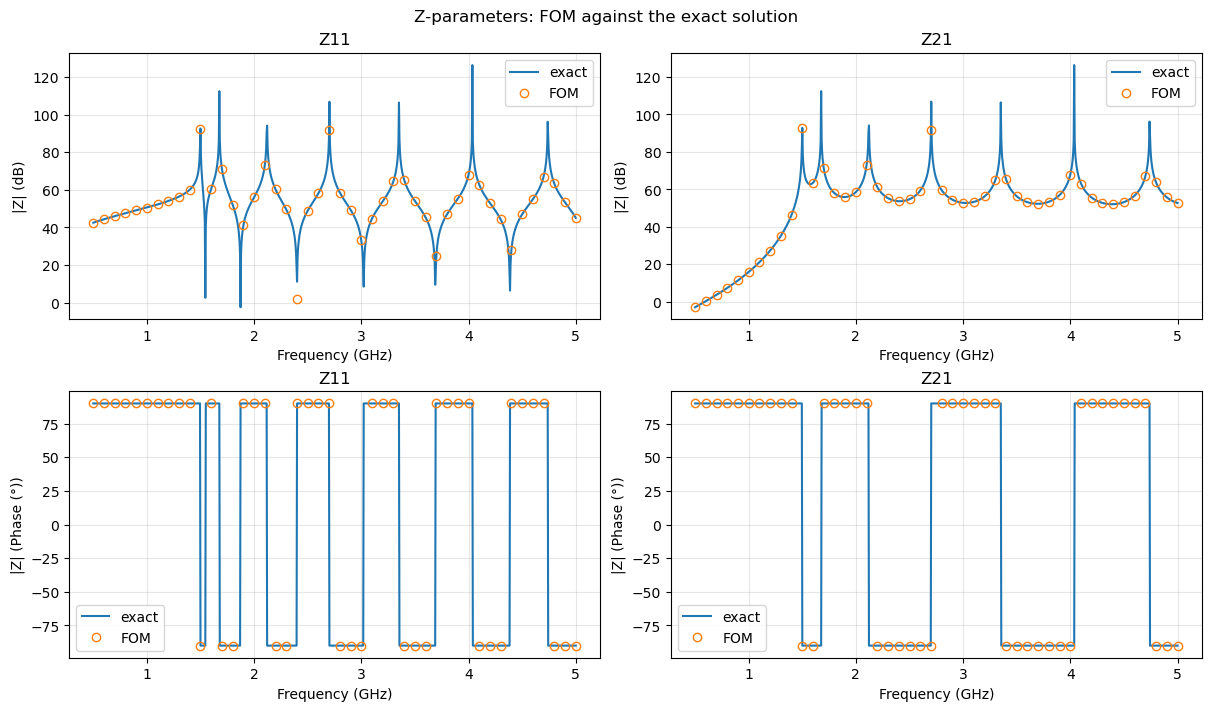

In [11]:
fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_z([label], plot_type=kind, ax=ax, label="exact")
        fom.plot_z([label], plot_type=kind, ax=ax, label="FOM",
                   lw=0, marker="o", mfc="none", title=f"Z{ij}")
fig.suptitle("Z-parameters: FOM against the exact solution")
plt.show()

Above cutoff $|Z|$ has sharp peaks, where the phase jumps by 180°. These are
resonances of the guide section; a later tutorial computes them directly.
With a sample every 0.1 GHz the circles land near the peaks but rarely on
top of them: the next tutorial fills the gaps.

### 3.3 Measure the difference

The same comparison as numbers: the difference between the computed and the
exact $S_{21}$ at every sample. `ana.s_parameters` takes frequencies in GHz.

In [12]:
import numpy as np

S21_exact = ana.s_parameters(f / 1e9)["S21"]
err = np.abs(S[:, 1, 0] - S21_exact)
k = np.argmax(err)
print(f"median |S21(FOM) - S21(exact)| = {np.median(err):.1e}")
print(f"largest                        = {err[k]:.1e} at {f[k] / 1e9:.1f} GHz")

median |S21(FOM) - S21(exact)| = 6.7e-05
largest                        = 3.9e-03 at 5.0 GHz


The difference is the discretisation error of the mesh (`maxh=0.02`) and the
element order. It is largest at the top of the band, where the wavelength is
shortest compared to the mesh elements. [How to choose the mesh size and
element order](../../how-to/mesh_and_order.md) shows how to reduce it.

## 4. Reopen the project

### 4.1 Load it from disk

Everything was saved while we worked. We open the project again, as you would
in a new session, by creating an `EMProject` with the same name **without**
`overwrite=True`.

In [13]:
proj = EMProject(name="first_simulation", base_dir="./simulations")

proj.parts

✅ Project 'first_simulation' exists. Loading...



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 642

Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 642


Restored PortEigenmodeSolver with 2 ports, 2 total modes
FrequencyDomainSolver state loaded from simulations\first_simulation\fds
✅ Project 'first_simulation' loaded.


{'guide': <cavsim3d.geometry.primitives.RectangularWaveguide at 0x25310fd3a50>}

The output says `Project 'first_simulation' exists. Loading...`, and the part
is back.

### 4.2 Ask for the same sweep again

In [14]:
res_again = proj.fds.solve(fmin=0.5, fmax=5.0, nsamples=46)
print("same results:", np.allclose(res_again["S"], S))

✅   Returning cached results. (Use rerun=True to force recompute)


same results: True


This time no sweep runs (`Returning cached results`): the request is identical
to the saved one, so `solve()` returns the stored results. A different
request, for example another frequency range, is computed afresh.

### 4.3 Look inside the project folder

In [15]:
from pathlib import Path

for p in sorted(Path("simulations/first_simulation").rglob("*")):
    if p.is_dir():
        print(p.relative_to("simulations"))

first_simulation\fds
first_simulation\fds\fom
first_simulation\fds\fom\eigenmodes
first_simulation\fds\fom\matrices
first_simulation\fds\fom\s
first_simulation\fds\fom\snapshots
first_simulation\fds\fom\z
first_simulation\fds\port_modes
first_simulation\geometry
first_simulation\mesh


The project holds the geometry, the mesh and, under `fds/fom/`, the solver's
matrices and its S- and Z-parameters.

## What we did

We created a project, added a rectangular waveguide, inspected its mesh and
ports, ran a frequency sweep across the cutoff, read and plotted the S- and
Z-parameters, confirmed them against the exact solution, and reopened the
saved project.

**Next:** [Build a reduced-order model](reduced_order_model.ipynb) turns these
46 samples into a model that sweeps thousands of frequencies in a fraction of
a second.

**Background:** [The project folder](../../explanation/project_layout.md)
explains what each folder holds and when results are reused or recomputed.